# Masked-reconstruction validation

Sanity check that the pretrained `old_13M` BrainLM checkpoint is "working": mask out
every token of one subject's 200-TR window in a deterministic sweep, ask the model to
predict each masked token, stitch the predictions back into a full `[424, 200]`
reconstruction, and compare it against the real signal -- visually and quantitatively.

Adapted from the upstream reference notebook
`BrainLM/inference_05_reconstruct_whole_recording.ipynb` (`construct_noise` /
`aggregate_predictions` pattern), simplified to a single subject / single window and
wired to this repo's local data + the vetted `run_model.py` loaders instead of the
UKBioBank HF-dataset pipeline that notebook used.

In [3]:
import os
import sys

# Cap CPU threads BEFORE importing heavy libraries (same convention as run_model.py)
MAX_CPU_THREADS = 4
os.environ["OMP_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["OPENBLAS_NUM_THREADS"] = str(MAX_CPU_THREADS)

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_num_threads(MAX_CPU_THREADS)

# validation/ is one level below the repo root, unlike attention_by_window.ipynb
sys.path.insert(0, os.path.abspath(".."))
from run_model import load_brainlm_model, load_spatial_coordinates, preprocess_subject_data

# run_model imports visualize_attention, which calls matplotlib.use("Agg") for
# headless script runs -- re-enable the inline backend for this notebook.
get_ipython().run_line_magic("matplotlib", "inline")


In [4]:
# --- Config ---
INPUT_H5 = "../data/input/fmri_timeseries_subset_100.h5"
COORDS = "../data/input/toolkit/atlases/A424_Coordinates.dat"
HF_REPO = "vandijklab/brainlm"
SUBFOLDER = "old_13M"

SUBJECT_INDEX = 0     # Sub_0000
WINDOW_INDEX = 0      # which of the 3 standard sliding windows to reconstruct (TRs 0-200)
NUM_WINDOWS = 3        # must match preprocess_subject_data's slicing used elsewhere in the repo
WINDOW_SIZE = 200

MASK_RATIO = 0.5       # fraction of tokens masked per sweep pass (old_13M's own config value is 0.0;
                       # run_model.py's loader forces that for attention extraction, so we set our own here)
RANDOM_SEED = 0

REGIONS_TO_PLOT = [0, 80, 160, 240, 320, 400]  # spread across the atlas for the timeseries comparison

FIGURES_DIR = "figures"
OUTPUTS_DIR = "outputs"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model, config = load_brainlm_model(HF_REPO, SUBFOLDER)
model.to(device)
model.eval()
# load_brainlm_model sets mask_ratio=0.0 (needed for run_model.py's attention extraction);
# override it here since this notebook's whole point is to mask tokens.
model.config.mask_ratio = MASK_RATIO

spatial_coords = load_spatial_coordinates(COORDS).to(device)  # [1, 424, 3], batch already matches our batch_size=1

num_regions = config.num_brain_voxels
num_patches = WINDOW_SIZE // config.timepoint_patching_size
patch_size = config.timepoint_patching_size
seq_len = num_regions * num_patches

print(f"num_regions={num_regions}, num_patches={num_patches}, patch_size={patch_size}, seq_len={seq_len}")
print(f"mask_ratio={model.config.mask_ratio}")


Device: cpu


/home/fmoss/miniforge3/envs/brainlm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/fmoss/miniforge3/envs/brainlm/lib/python3.10/site-packages/accelerate/utils/torch_xla.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
loading weights file pytorch_model.bin from cache at /home/fmoss/.cache/huggingface/hub/models--vandijklab--brainlm/snapshots/4c54e0cccf920d9d6af7c647cb866fc19c60cf26/old_13M/pytorch_model.bin
All model checkpoint weights were used when initializing BrainLMForPretraining.

All the weights of BrainLMForPretraining were initialized from the model checkpoint at vandi

num_regions=424, num_patches=10, patch_size=20, seq_len=4240
mask_ratio=0.5


In [6]:
with h5py.File(INPUT_H5, "r") as f:
    sub_id = f["subject_ids"][SUBJECT_INDEX].decode("utf-8")
    raw_data = f["parcel_ts"][SUBJECT_INDEX, :, :]

fmri_windows = preprocess_subject_data(raw_data, num_windows=NUM_WINDOWS, window_size=WINDOW_SIZE)
x = fmri_windows[WINDOW_INDEX : WINDOW_INDEX + 1].to(device)  # [1, 424, 200], keep the batch dim

print(f"Subject: {sub_id}, window {WINDOW_INDEX}, input shape: {tuple(x.shape)}")


Subject: Sub_0000, window 0, input shape: (1, 424, 200)


## Deterministic full-coverage mask sweep

`construct_noise` builds a noise tensor for `model(...)`'s `noise=` kwarg so that
`argsort(noise)`'s masked set (the largest-noise tokens) never repeats a
previously-masked token -- forcing already-masked positions' noise to `0` (smallest,
so they always sort into the "keep" side). Repeating this until every token has been
masked at least once means every timepoint gets predicted by the decoder while
*unseen* by the encoder, giving a genuine reconstruction rather than a copy of the
input.

In [7]:
def construct_noise(batch_size, seq_length, mask_ratio, device, ids_mask=None):
    """Returns (noise, ids_mask) where ids_mask accumulates every token index masked
    so far, and noise is built so this call's masked tokens are all new."""
    len_mask = int(mask_ratio * seq_length)
    noise = torch.rand(batch_size, seq_length, device=device)
    if ids_mask is not None:
        noise.scatter_(dim=1, index=ids_mask, value=0.0)  # force-keep already-masked tokens
        ids_shuffle = torch.argsort(noise, dim=1)          # ascending: small = keep, large = mask
        ids_mask = torch.cat([ids_mask, ids_shuffle[:, -len_mask:]], dim=1)
    else:
        ids_mask = torch.argsort(noise, dim=1)[:, -len_mask:]
    return noise, ids_mask


def aggregate_predictions(predictions, masks, mode="first"):
    """Stitches per-pass masked predictions into one full reconstruction.
    mode='first' keeps only the first prediction made for each token (matters when
    mask_ratio doesn't evenly divide seq_len and some tokens get masked twice)."""
    preds = torch.zeros_like(predictions[0])
    cum_mask = torch.zeros_like(masks[0])
    for p, m in zip(predictions, masks):
        take = (m == 1) & (cum_mask == 0) if mode == "first" else (m == 1)
        preds += p * take.unsqueeze(-1)
        cum_mask += m
    if mode == "mean":
        preds = preds / cum_mask.clamp(min=1).unsqueeze(-1)
    return preds, cum_mask


In [8]:
torch.manual_seed(RANDOM_SEED)

masked_tokens = 0
ids_removed = None
predictions, masks = [], []
sweep_pass = 0

while masked_tokens < seq_len:
    noise, ids_removed = construct_noise(x.shape[0], seq_len, MASK_RATIO, device, ids_removed)

    with torch.no_grad():
        out = model(signal_vectors=x, xyz_vectors=spatial_coords, noise=noise)

    logits = out.logits[0] if isinstance(out.logits, tuple) else out.logits  # [1, num_regions, num_patches, patch_size]
    predictions.append(logits[0].detach().cpu())
    masks.append(out.mask[0].detach().cpu())

    masked_tokens += out.mask[0].sum().item()
    sweep_pass += 1
    print(f"pass {sweep_pass}: {int(masked_tokens)}/{seq_len} tokens masked+predicted so far")

pred_logits, cum_mask = aggregate_predictions(predictions, masks, mode="first")
assert (cum_mask >= 1).all(), "Not every token was masked at least once -- reconstruction is incomplete"
print(f"Done in {sweep_pass} passes.")


pass 1: 2120/4240 tokens masked+predicted so far
pass 2: 4240/4240 tokens masked+predicted so far
Done in 2 passes.


In [10]:
reconstructed = pred_logits.reshape(num_regions, num_patches * patch_size).numpy()
ground_truth = x[0].cpu().numpy()

print("reconstructed shape:", reconstructed.shape, "| ground_truth shape:", ground_truth.shape)

np.save(os.path.join(OUTPUTS_DIR, f"{sub_id}_w{WINDOW_INDEX}_reconstructed.npy"), reconstructed.astype("float32"))
np.save(os.path.join(OUTPUTS_DIR, f"{sub_id}_w{WINDOW_INDEX}_ground_truth.npy"), ground_truth.astype("float32"))


reconstructed shape: (424, 200) | ground_truth shape: (424, 200)


## Best-performing regions (top 5 by correlation)

Top 5 best-reconstructed regions:
  1. region 408  r = 0.680
  2. region 403  r = 0.677
  3. region 406  r = 0.671
  4. region 256  r = 0.661
  5. region  83  r = 0.654


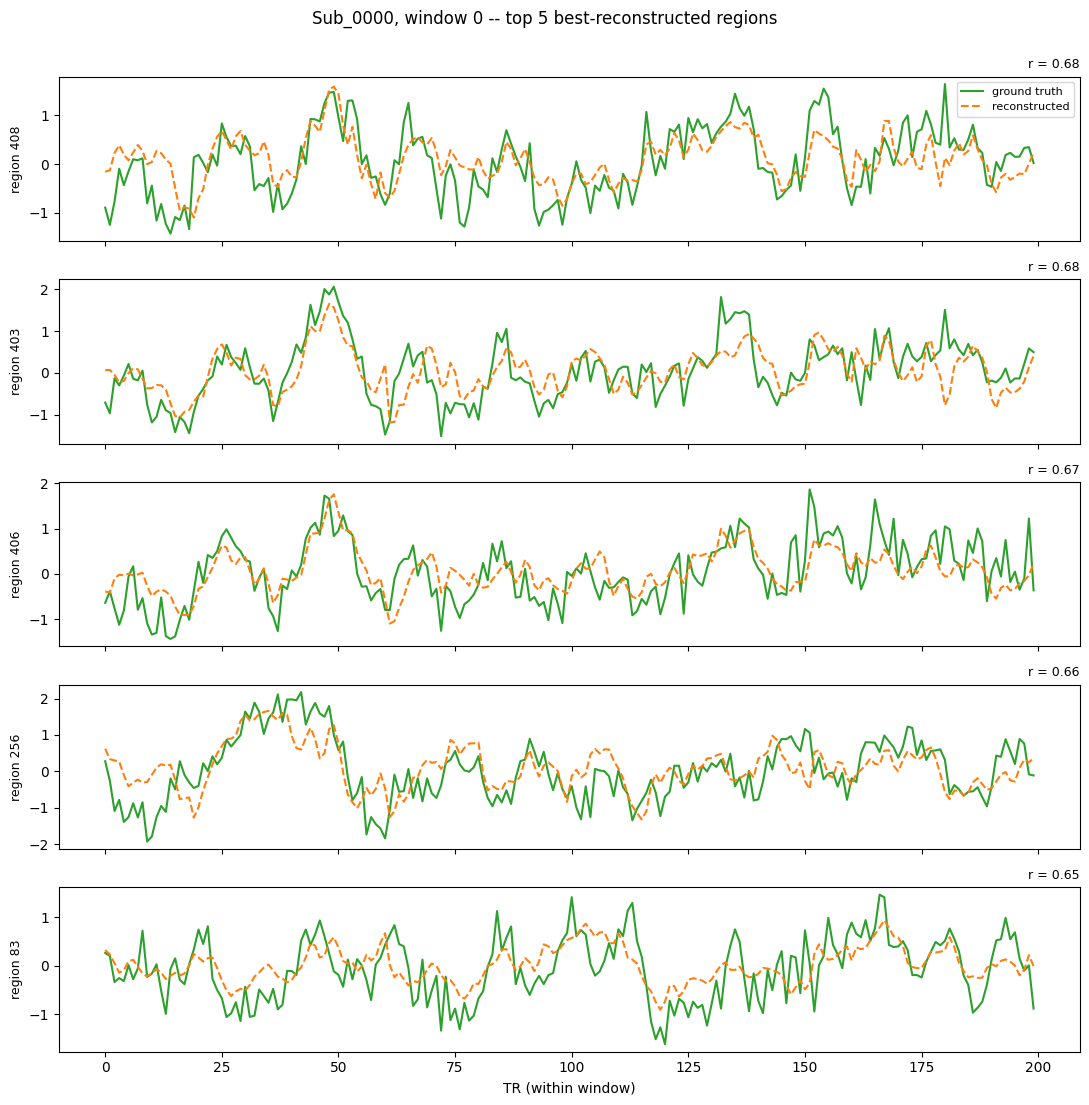

In [11]:
region_corr_preview = np.array([
    np.corrcoef(ground_truth[i], reconstructed[i])[0, 1] for i in range(num_regions)
])
top5 = np.argsort(np.nan_to_num(region_corr_preview, nan=-np.inf))[-5:][::-1]

print("Top 5 best-reconstructed regions:")
for rank, region in enumerate(top5, start=1):
    print(f"  {rank}. region {region:>3d}  r = {region_corr_preview[region]:.3f}")

fig, axes = plt.subplots(len(top5), 1, figsize=(11, 2.2 * len(top5)), sharex=True)

for ax, region in zip(axes, top5):
    ax.plot(ground_truth[region], label="ground truth", color="tab:green", linewidth=1.5)
    ax.plot(reconstructed[region], label="reconstructed", color="tab:orange", linewidth=1.5, linestyle="--")
    ax.set_ylabel(f"region {region}", fontsize=9)
    ax.set_title(f"r = {region_corr_preview[region]:.2f}", fontsize=9, loc="right")

axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("TR (within window)")
fig.suptitle(f"{sub_id}, window {WINDOW_INDEX} -- top 5 best-reconstructed regions", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_w{WINDOW_INDEX}_top5_regions.png"), dpi=130, bbox_inches="tight")
plt.show()


## Visual comparison: ground truth vs reconstruction, a few regions

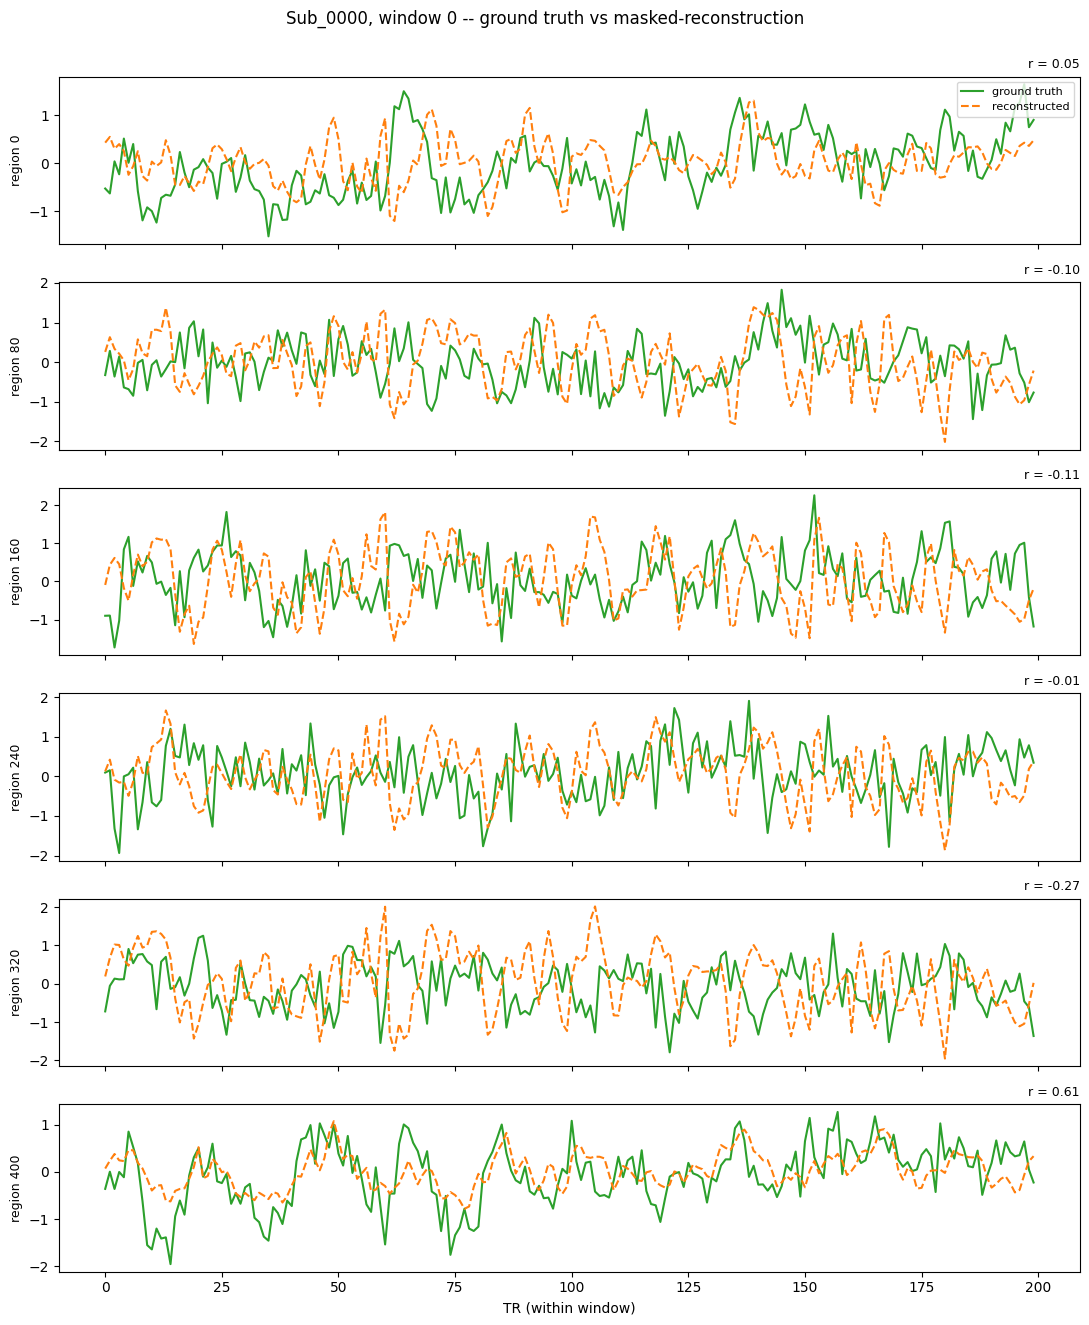

In [12]:
fig, axes = plt.subplots(len(REGIONS_TO_PLOT), 1, figsize=(11, 2.2 * len(REGIONS_TO_PLOT)), sharex=True)

for ax, region in zip(axes, REGIONS_TO_PLOT):
    ax.plot(ground_truth[region], label="ground truth", color="tab:green", linewidth=1.5)
    ax.plot(reconstructed[region], label="reconstructed", color="tab:orange", linewidth=1.5, linestyle="--")
    r = np.corrcoef(ground_truth[region], reconstructed[region])[0, 1]
    ax.set_ylabel(f"region {region}", fontsize=9)
    ax.set_title(f"r = {r:.2f}", fontsize=9, loc="right")

axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("TR (within window)")
fig.suptitle(f"{sub_id}, window {WINDOW_INDEX} -- ground truth vs masked-reconstruction", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_w{WINDOW_INDEX}_reconstruction_timeseries.png"), dpi=130, bbox_inches="tight")
plt.show()


## Quantitative check: per-region correlation, overall fit

In [13]:
region_corr = np.array([
    np.corrcoef(ground_truth[i], reconstructed[i])[0, 1] for i in range(num_regions)
])
mse = float(np.mean((ground_truth - reconstructed) ** 2))

print(f"Per-region correlation: mean={np.nanmean(region_corr):.3f}, median={np.nanmedian(region_corr):.3f}, "
      f"min={np.nanmin(region_corr):.3f}, max={np.nanmax(region_corr):.3f}")
print(f"Overall MSE (reconstructed vs ground truth): {mse:.4f}")
print(f"Regions with NaN correlation (near-zero variance): {int(np.isnan(region_corr).sum())}")


Per-region correlation: mean=0.015, median=-0.022, min=-0.454, max=0.680
Overall MSE (reconstructed vs ground truth): 0.8874
Regions with NaN correlation (near-zero variance): 0


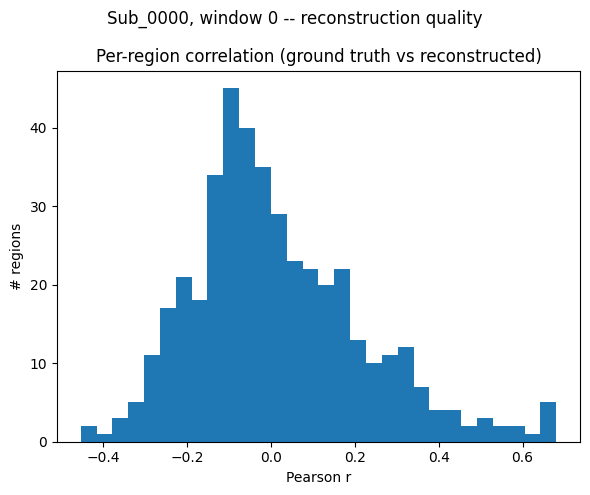

In [16]:
gt_flat = ground_truth.ravel()
recon_flat = reconstructed.ravel()
overall_r = np.corrcoef(gt_flat, recon_flat)[0, 1]
slope, intercept = np.polyfit(gt_flat, recon_flat, 1)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.hist(region_corr, bins=30, color="tab:blue")
ax.set_title("Per-region correlation (ground truth vs reconstructed)")
ax.set_xlabel("Pearson r")
ax.set_ylabel("# regions")

fig.suptitle(f"{sub_id}, window {WINDOW_INDEX} -- reconstruction quality")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_w{WINDOW_INDEX}_reconstruction_quality.png"), dpi=130, bbox_inches="tight")
plt.show()
